In [7]:
import pandas as pd
import numpy as np

# Task
Implement Gradient Boosting Machines (GBM) from scratch for a regression task. This involves providing an algorithm introduction, implementing a loss function and its negative gradient, creating a decision stump/tree as a base learner, building the core GBM greedy function approximation, developing a prediction method, and demonstrating its usage on a synthetic dataset.

## Algorithm Introduction

### Subtask:
Provide a brief introduction to Gradient Boosting Machines (GBM) as a greedy function approximation method, explaining the core concepts outlined in Friedman's paper.


## Introduction to Gradient Boosting Machines (GBM)

Gradient Boosting Machines (GBM) represent a powerful and widely used ensemble learning technique for both regression and classification tasks. It operates as a **greedy function approximation method**, where the model is built sequentially by combining multiple simpler, weaker models (often decision trees).

The core idea behind GBM, significantly popularized by Friedman's work, is to iteratively improve the model's predictions by focusing on the errors of the previous iterations. In each step, a new weak learner is trained to predict the **negative gradient of the loss function** with respect to the current ensemble's predictions. Essentially, instead of directly fitting the new model to the residuals (the difference between the observed and predicted values), it fits to the *direction of the steepest descent* of the loss function. This process allows the model to progressively correct the mistakes made by the prior learners, leading to a highly accurate and robust predictive model.

## Loss Function and Negative Gradient

### Subtask:
Implement a loss function (e.g., Mean Squared Error for regression) and its negative gradient. This is crucial as GBM iteratively fits base learners to these negative gradients.


**Reasoning**:
Implement the `mse_loss` and `mse_negative_gradient` functions as described in the instructions, including comments for clarity.



In [8]:
def mse_loss(y_true, y_pred):
    """
    Calculates the Mean Squared Error (MSE) between true and predicted values.

    Args:
        y_true (array-like): True target values.
        y_pred (array-like): Predicted target values.

    Returns:
        float: The Mean Squared Error.
    """
    return np.mean((y_true - y_pred)**2)

def mse_negative_gradient(y_true, y_pred):
    """
    Calculates the negative gradient of the Mean Squared Error with respect to the predictions.
    For MSE, the negative gradient is (y_true - y_pred).

    Args:
        y_true (array-like): True target values.
        y_pred (array-like): Predicted target values.

    Returns:
        array-like: The negative gradient for each prediction.
    """
    return y_true - y_pred

print("MSE loss and negative gradient functions are defined.")

MSE loss and negative gradient functions are defined.


## Base Learner Implementation (Decision Stump/Tree)

### Subtask:
Create a simple decision tree (or decision stump) from scratch to serve as the weak learner. This will involve implementing splitting criteria and prediction for individual trees.


**Reasoning**:
I will start by defining the `Node` class which is a fundamental building block for the decision tree, and then define the `DecisionTreeRegressor` class with its initializer, including parameters for controlling tree growth such as `max_depth` and `min_samples_split`.



In [9]:
class Node:
    """
    Represents a node in the decision tree.
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        # For decision node
        self.feature_index = feature_index  # Index of the feature to split on
        self.threshold = threshold          # Threshold value for the split
        self.left = left                    # Left child node
        self.right = right                  # Right child node

        # For leaf node
        self.value = value                  # Predicted value if it's a leaf node

class DecisionTreeRegressor:
    """
    A simple Decision Tree Regressor implementation.
    """
    def __init__(self, max_depth=1, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None # The root node of the tree

    print("Node and DecisionTreeRegressor classes defined with initializer.")

Node and DecisionTreeRegressor classes defined with initializer.


**Reasoning**:
Now that the basic class structure is defined, I will implement the `_best_split` private method inside the `DecisionTreeRegressor` class. This method will find the best feature and threshold to split the data, based on minimizing the Mean Squared Error (MSE).



In [10]:
class Node:
    """
    Represents a node in the decision tree.
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        # For decision node
        self.feature_index = feature_index  # Index of the feature to split on
        self.threshold = threshold          # Threshold value for the split
        self.left = left                    # Left child node
        self.right = right                  # Right child node

        # For leaf node
        self.value = value                  # Predicted value if it's a leaf node

class DecisionTreeRegressor:
    """
    A simple Decision Tree Regressor implementation.
    """
    def __init__(self, max_depth=1, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None # The root node of the tree

    def _best_split(self, X, y):
        """
        Finds the best feature and threshold to split the data.
        It aims to minimize the Mean Squared Error (MSE) of the split.
        """
        n_samples, n_features = X.shape
        if n_samples <= self.min_samples_split:
            return None, None

        # Calculate MSE of the parent node (before splitting)
        parent_mse = np.mean((y - np.mean(y))**2)
        best_gain = 0 # Maximize information gain or minimize weighted MSE of children
        best_feature_index = None
        best_threshold = None

        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)

            for threshold in possible_thresholds:
                # Split data based on the current feature and threshold
                left_indices = np.where(feature_values <= threshold)[0]
                right_indices = np.where(feature_values > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                # Calculate weighted MSE of children
                y_left, y_right = y[left_indices], y[right_indices]

                mse_left = np.mean((y_left - np.mean(y_left))**2) if len(y_left) > 0 else 0
                mse_right = np.mean((y_right - np.mean(y_right))**2) if len(y_right) > 0 else 0

                n_left, n_right = len(y_left), len(y_right)
                weighted_mse_children = (n_left * mse_left + n_right * mse_right) / n_samples

                # Calculate reduction in MSE (gain)
                gain = parent_mse - weighted_mse_children

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold

        return best_feature_index, best_threshold

print("DecisionTreeRegressor class updated with _best_split method.")


DecisionTreeRegressor class updated with _best_split method.


**Reasoning**:
I will implement the `_split` private method inside the `DecisionTreeRegressor` class. This method will take the dataset, a feature index, and a threshold, and return the left and right subsets of the data based on the split.



In [11]:
class Node:
    """
    Represents a node in the decision tree.
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        # For decision node
        self.feature_index = feature_index  # Index of the feature to split on
        self.threshold = threshold          # Threshold value for the split
        self.left = left                    # Left child node
        self.right = right                  # Right child node

        # For leaf node
        self.value = value                  # Predicted value if it's a leaf node

class DecisionTreeRegressor:
    """
    A simple Decision Tree Regressor implementation.
    """
    def __init__(self, max_depth=1, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None # The root node of the tree

    def _best_split(self, X, y):
        """
        Finds the best feature and threshold to split the data.
        It aims to minimize the Mean Squared Error (MSE) of the split.
        """
        n_samples, n_features = X.shape
        if n_samples <= self.min_samples_split:
            return None, None

        # Calculate MSE of the parent node (before splitting)
        parent_mse = np.mean((y - np.mean(y))**2)
        best_gain = 0 # Maximize information gain or minimize weighted MSE of children
        best_feature_index = None
        best_threshold = None

        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)

            for threshold in possible_thresholds:
                # Split data based on the current feature and threshold
                left_indices = np.where(feature_values <= threshold)[0]
                right_indices = np.where(feature_values > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                # Calculate weighted MSE of children
                y_left, y_right = y[left_indices], y[right_indices]

                mse_left = np.mean((y_left - np.mean(y_left))**2) if len(y_left) > 0 else 0
                mse_right = np.mean((y_right - np.mean(y_right))**2) if len(y_right) > 0 else 0

                n_left, n_right = len(y_left), len(y_right)
                weighted_mse_children = (n_left * mse_left + n_right * mse_right) / n_samples

                # Calculate reduction in MSE (gain)
                gain = parent_mse - weighted_mse_children

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold

        return best_feature_index, best_threshold

    def _split(self, X, y, feature_index, threshold):
        """
        Splits the dataset into left and right subsets based on a feature and threshold.
        """
        left_indices = np.where(X[:, feature_index] <= threshold)[0]
        right_indices = np.where(X[:, feature_index] > threshold)[0]

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        return X_left, y_left, X_right, y_right

print("DecisionTreeRegressor class updated with _split method.")

DecisionTreeRegressor class updated with _split method.


**Reasoning**:
Now, I will implement the `_leaf_value` private method inside the `DecisionTreeRegressor` class. This method calculates the prediction for a leaf node, which for regression, is the mean of the target values in that node.



In [12]:
class Node:
    """
    Represents a node in the decision tree.
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        # For decision node
        self.feature_index = feature_index  # Index of the feature to split on
        self.threshold = threshold          # Threshold value for the split
        self.left = left                    # Left child node
        self.right = right                  # Right child node

        # For leaf node
        self.value = value                  # Predicted value if it's a leaf node

class DecisionTreeRegressor:
    """
    A simple Decision Tree Regressor implementation.
    """
    def __init__(self, max_depth=1, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None # The root node of the tree

    def _best_split(self, X, y):
        """
        Finds the best feature and threshold to split the data.
        It aims to minimize the Mean Squared Error (MSE) of the split.
        """
        n_samples, n_features = X.shape
        if n_samples <= self.min_samples_split:
            return None, None

        # Calculate MSE of the parent node (before splitting)
        parent_mse = np.mean((y - np.mean(y))**2)
        best_gain = 0 # Maximize information gain or minimize weighted MSE of children
        best_feature_index = None
        best_threshold = None

        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)

            for threshold in possible_thresholds:
                # Split data based on the current feature and threshold
                left_indices = np.where(feature_values <= threshold)[0]
                right_indices = np.where(feature_values > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                # Calculate weighted MSE of children
                y_left, y_right = y[left_indices], y[right_indices]

                mse_left = np.mean((y_left - np.mean(y_left))**2) if len(y_left) > 0 else 0
                mse_right = np.mean((y_right - np.mean(y_right))**2) if len(y_right) > 0 else 0

                n_left, n_right = len(y_left), len(y_right)
                weighted_mse_children = (n_left * mse_left + n_right * mse_right) / n_samples

                # Calculate reduction in MSE (gain)
                gain = parent_mse - weighted_mse_children

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold

        return best_feature_index, best_threshold

    def _split(self, X, y, feature_index, threshold):
        """
        Splits the dataset into left and right subsets based on a feature and threshold.
        """
        left_indices = np.where(X[:, feature_index] <= threshold)[0]
        right_indices = np.where(X[:, feature_index] > threshold)[0]

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        return X_left, y_left, X_right, y_right

    def _leaf_value(self, y):
        """
        Calculates the prediction for a leaf node (mean of target values).
        """
        if len(y) == 0:
            return 0
        return np.mean(y)

print("DecisionTreeRegressor class updated with _leaf_value method.")

DecisionTreeRegressor class updated with _leaf_value method.


**Reasoning**:
Now, I will implement the private recursive method, `_grow_tree`, inside the `DecisionTreeRegressor` class. This method is responsible for recursively building the decision tree by finding the best splits and creating child nodes until the maximum depth or minimum samples split criteria are met.



In [13]:
class Node:
    """
    Represents a node in the decision tree.
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        # For decision node
        self.feature_index = feature_index  # Index of the feature to split on
        self.threshold = threshold          # Threshold value for the split
        self.left = left                    # Left child node
        self.right = right                  # Right child node

        # For leaf node
        self.value = value                  # Predicted value if it's a leaf node

class DecisionTreeRegressor:
    """
    A simple Decision Tree Regressor implementation.
    """
    def __init__(self, max_depth=1, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None # The root node of the tree

    def _best_split(self, X, y):
        """
        Finds the best feature and threshold to split the data.
        It aims to minimize the Mean Squared Error (MSE) of the split.
        """
        n_samples, n_features = X.shape
        if n_samples <= self.min_samples_split:
            return None, None

        # Calculate MSE of the parent node (before splitting)
        parent_mse = np.mean((y - np.mean(y))**2)
        best_gain = 0 # Maximize information gain or minimize weighted MSE of children
        best_feature_index = None
        best_threshold = None

        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)

            for threshold in possible_thresholds:
                # Split data based on the current feature and threshold
                left_indices = np.where(feature_values <= threshold)[0]
                right_indices = np.where(feature_values > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                # Calculate weighted MSE of children
                y_left, y_right = y[left_indices], y[right_indices]

                mse_left = np.mean((y_left - np.mean(y_left))**2) if len(y_left) > 0 else 0
                mse_right = np.mean((y_right - np.mean(y_right))**2) if len(y_right) > 0 else 0

                n_left, n_right = len(y_left), len(y_right)
                weighted_mse_children = (n_left * mse_left + n_right * mse_right) / n_samples

                # Calculate reduction in MSE (gain)
                gain = parent_mse - weighted_mse_children

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold

        return best_feature_index, best_threshold

    def _split(self, X, y, feature_index, threshold):
        """
        Splits the dataset into left and right subsets based on a feature and threshold.
        """
        left_indices = np.where(X[:, feature_index] <= threshold)[0]
        right_indices = np.where(X[:, feature_index] > threshold)[0]

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        return X_left, y_left, X_right, y_right

    def _leaf_value(self, y):
        """
        Calculates the prediction for a leaf node (mean of target values).
        """
        if len(y) == 0:
            return 0
        return np.mean(y)

    def _grow_tree(self, X, y, depth):
        """
        Recursively builds the decision tree.
        """
        n_samples, n_features = X.shape

        # Stop splitting if max_depth is reached or min_samples_split is not met
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return Node(value=self._leaf_value(y))

        best_feature, best_threshold = self._best_split(X, y)

        # If no good split found, make it a leaf node
        if best_feature is None:
            return Node(value=self._leaf_value(y))

        # Split the data
        X_left, y_left, X_right, y_right = self._split(X, y, best_feature, best_threshold)

        # Recursively build left and right subtrees
        left_child = self._grow_tree(X_left, y_left, depth + 1)
        right_child = self._grow_tree(X_right, y_right, depth + 1)

        return Node(feature_index=best_feature, threshold=best_threshold, left=left_child, right=right_child)

print("DecisionTreeRegressor class updated with _grow_tree method.")

DecisionTreeRegressor class updated with _grow_tree method.


**Reasoning**:
Now, I will implement the public `fit` method for `DecisionTreeRegressor`. This method will take training data `X` and `y`, initialize the root of the tree, and call the `_grow_tree` method to build the tree.



In [14]:
class Node:
    """
    Represents a node in the decision tree.
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        # For decision node
        self.feature_index = feature_index  # Index of the feature to split on
        self.threshold = threshold          # Threshold value for the split
        self.left = left                    # Left child node
        self.right = right                  # Right child node

        # For leaf node
        self.value = value                  # Predicted value if it's a leaf node

class DecisionTreeRegressor:
    """
    A simple Decision Tree Regressor implementation.
    """
    def __init__(self, max_depth=1, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None # The root node of the tree

    def _best_split(self, X, y):
        """
        Finds the best feature and threshold to split the data.
        It aims to minimize the Mean Squared Error (MSE) of the split.
        """
        n_samples, n_features = X.shape
        if n_samples <= self.min_samples_split:
            return None, None

        # Calculate MSE of the parent node (before splitting)
        parent_mse = np.mean((y - np.mean(y))**2)
        best_gain = 0 # Maximize information gain or minimize weighted MSE of children
        best_feature_index = None
        best_threshold = None

        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)

            for threshold in possible_thresholds:
                # Split data based on the current feature and threshold
                left_indices = np.where(feature_values <= threshold)[0]
                right_indices = np.where(feature_values > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                # Calculate weighted MSE of children
                y_left, y_right = y[left_indices], y[right_indices]

                mse_left = np.mean((y_left - np.mean(y_left))**2) if len(y_left) > 0 else 0
                mse_right = np.mean((y_right - np.mean(y_right))**2) if len(y_right) > 0 else 0

                n_left, n_right = len(y_left), len(y_right)
                weighted_mse_children = (n_left * mse_left + n_right * mse_right) / n_samples

                # Calculate reduction in MSE (gain)
                gain = parent_mse - weighted_mse_children

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold

        return best_feature_index, best_threshold

    def _split(self, X, y, feature_index, threshold):
        """
        Splits the dataset into left and right subsets based on a feature and threshold.
        """
        left_indices = np.where(X[:, feature_index] <= threshold)[0]
        right_indices = np.where(X[:, feature_index] > threshold)[0]

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        return X_left, y_left, X_right, y_right

    def _leaf_value(self, y):
        """
        Calculates the prediction for a leaf node (mean of target values).
        """
        if len(y) == 0:
            return 0
        return np.mean(y)

    def _grow_tree(self, X, y, depth):
        """
        Recursively builds the decision tree.
        """
        n_samples, n_features = X.shape

        # Stop splitting if max_depth is reached or min_samples_split is not met
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return Node(value=self._leaf_value(y))

        best_feature, best_threshold = self._best_split(X, y)

        # If no good split found, make it a leaf node
        if best_feature is None:
            return Node(value=self._leaf_value(y))

        # Split the data
        X_left, y_left, X_right, y_right = self._split(X, y, best_feature, best_threshold)

        # Recursively build left and right subtrees
        left_child = self._grow_tree(X_left, y_left, depth + 1)
        right_child = self._grow_tree(X_right, y_right, depth + 1)

        return Node(feature_index=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        """
        Builds the decision tree regressor from the training data.
        """
        self.root = self._grow_tree(X, y, depth=0)

print("DecisionTreeRegressor class updated with fit method.")

DecisionTreeRegressor class updated with fit method.


**Reasoning**:
Now, I will implement the private recursive method, `_predict_tree`, inside the `DecisionTreeRegressor` class. This method will traverse the built tree for a single input sample `x` and return its predicted value by following the decision rules from the root down to a leaf node.



In [15]:
class Node:
    """
    Represents a node in the decision tree.
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        # For decision node
        self.feature_index = feature_index  # Index of the feature to split on
        self.threshold = threshold          # Threshold value for the split
        self.left = left                    # Left child node
        self.right = right                  # Right child node

        # For leaf node
        self.value = value                  # Predicted value if it's a leaf node

class DecisionTreeRegressor:
    """
    A simple Decision Tree Regressor implementation.
    """
    def __init__(self, max_depth=1, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None # The root node of the tree

    def _best_split(self, X, y):
        """
        Finds the best feature and threshold to split the data.
        It aims to minimize the Mean Squared Error (MSE) of the split.
        """
        n_samples, n_features = X.shape
        if n_samples <= self.min_samples_split:
            return None, None

        # Calculate MSE of the parent node (before splitting)
        parent_mse = np.mean((y - np.mean(y))**2)
        best_gain = 0 # Maximize information gain or minimize weighted MSE of children
        best_feature_index = None
        best_threshold = None

        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)

            for threshold in possible_thresholds:
                # Split data based on the current feature and threshold
                left_indices = np.where(feature_values <= threshold)[0]
                right_indices = np.where(feature_values > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                # Calculate weighted MSE of children
                y_left, y_right = y[left_indices], y[right_indices]

                mse_left = np.mean((y_left - np.mean(y_left))**2) if len(y_left) > 0 else 0
                mse_right = np.mean((y_right - np.mean(y_right))**2) if len(y_right) > 0 else 0

                n_left, n_right = len(y_left), len(y_right)
                weighted_mse_children = (n_left * mse_left + n_right * mse_right) / n_samples

                # Calculate reduction in MSE (gain)
                gain = parent_mse - weighted_mse_children

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold

        return best_feature_index, best_threshold

    def _split(self, X, y, feature_index, threshold):
        """
        Splits the dataset into left and right subsets based on a feature and threshold.
        """
        left_indices = np.where(X[:, feature_index] <= threshold)[0]
        right_indices = np.where(X[:, feature_index] > threshold)[0]

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        return X_left, y_left, X_right, y_right

    def _leaf_value(self, y):
        """
        Calculates the prediction for a leaf node (mean of target values).
        """
        if len(y) == 0:
            return 0
        return np.mean(y)

    def _grow_tree(self, X, y, depth):
        """
        Recursively builds the decision tree.
        """
        n_samples, n_features = X.shape

        # Stop splitting if max_depth is reached or min_samples_split is not met
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return Node(value=self._leaf_value(y))

        best_feature, best_threshold = self._best_split(X, y)

        # If no good split found, make it a leaf node
        if best_feature is None:
            return Node(value=self._leaf_value(y))

        # Split the data
        X_left, y_left, X_right, y_right = self._split(X, y, best_feature, best_threshold)

        # Recursively build left and right subtrees
        left_child = self._grow_tree(X_left, y_left, depth + 1)
        right_child = self._grow_tree(X_right, y_right, depth + 1)

        return Node(feature_index=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        """
        Builds the decision tree regressor from the training data.
        """
        self.root = self._grow_tree(X, y, depth=0)

    def _predict_tree(self, x, node):
        """
        Recursively traverses the tree to predict the value for a single sample x.
        """
        if node.value is not None:
            return node.value

        if x[node.feature_index] <= node.threshold:
            return self._predict_tree(x, node.left)
        else:
            return self._predict_tree(x, node.right)

print("DecisionTreeRegressor class updated with _predict_tree method.")

DecisionTreeRegressor class updated with _predict_tree method.


**Reasoning**:
Now, I will implement the public `predict` method for `DecisionTreeRegressor`. This method will take an array of samples `X` and use the `_predict_tree` method to return an array of predictions for the entire input dataset.



In [16]:
class Node:
    """
    Represents a node in the decision tree.
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        # For decision node
        self.feature_index = feature_index  # Index of the feature to split on
        self.threshold = threshold          # Threshold value for the split
        self.left = left                    # Left child node
        self.right = right                  # Right child node

        # For leaf node
        self.value = value                  # Predicted value if it's a leaf node

class DecisionTreeRegressor:
    """
    A simple Decision Tree Regressor implementation.
    """
    def __init__(self, max_depth=1, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None # The root node of the tree

    def _best_split(self, X, y):
        """
        Finds the best feature and threshold to split the data.
        It aims to minimize the Mean Squared Error (MSE) of the split.
        """
        n_samples, n_features = X.shape
        if n_samples <= self.min_samples_split:
            return None, None

        # Calculate MSE of the parent node (before splitting)
        parent_mse = np.mean((y - np.mean(y))**2)
        best_gain = 0 # Maximize information gain or minimize weighted MSE of children
        best_feature_index = None
        best_threshold = None

        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)

            for threshold in possible_thresholds:
                # Split data based on the current feature and threshold
                left_indices = np.where(feature_values <= threshold)[0]
                right_indices = np.where(feature_values > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                # Calculate weighted MSE of children
                y_left, y_right = y[left_indices], y[right_indices]

                mse_left = np.mean((y_left - np.mean(y_left))**2) if len(y_left) > 0 else 0
                mse_right = np.mean((y_right - np.mean(y_right))**2) if len(y_right) > 0 else 0

                n_left, n_right = len(y_left), len(y_right)
                weighted_mse_children = (n_left * mse_left + n_right * mse_right) / n_samples

                # Calculate reduction in MSE (gain)
                gain = parent_mse - weighted_mse_children

                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold

        return best_feature_index, best_threshold

    def _split(self, X, y, feature_index, threshold):
        """
        Splits the dataset into left and right subsets based on a feature and threshold.
        """
        left_indices = np.where(X[:, feature_index] <= threshold)[0]
        right_indices = np.where(X[:, feature_index] > threshold)[0]

        X_left, y_left = X[left_indices], y[left_indices]
        X_right, y_right = X[right_indices], y[right_indices]

        return X_left, y_left, X_right, y_right

    def _leaf_value(self, y):
        """
        Calculates the prediction for a leaf node (mean of target values).
        """
        if len(y) == 0:
            return 0
        return np.mean(y)

    def _grow_tree(self, X, y, depth):
        """
        Recursively builds the decision tree.
        """
        n_samples, n_features = X.shape

        # Stop splitting if max_depth is reached or min_samples_split is not met
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return Node(value=self._leaf_value(y))

        best_feature, best_threshold = self._best_split(X, y)

        # If no good split found, make it a leaf node
        if best_feature is None:
            return Node(value=self._leaf_value(y))

        # Split the data
        X_left, y_left, X_right, y_right = self._split(X, y, best_feature, best_threshold)

        # Recursively build left and right subtrees
        left_child = self._grow_tree(X_left, y_left, depth + 1)
        right_child = self._grow_tree(X_right, y_right, depth + 1)

        return Node(feature_index=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        """
        Builds the decision tree regressor from the training data.
        """
        self.root = self._grow_tree(X, y, depth=0)

    def _predict_tree(self, x, node):
        """
        Recursively traverses the tree to predict the value for a single sample x.
        """
        if node.value is not None:
            return node.value

        if x[node.feature_index] <= node.threshold:
            return self._predict_tree(x, node.left)
        else:
            return self._predict_tree(x, node.right)

    def predict(self, X):
        """
        Predicts values for an array of samples X.
        """
        if self.root is None:
            raise Exception("Tree not fitted. Call fit() first.")

        return np.array([self._predict_tree(x, self.root) for x in X])

print("DecisionTreeRegressor class updated with predict method.")

DecisionTreeRegressor class updated with predict method.


## Greedy Function Approximation (GBM) Core

### Subtask:
Implement the main boosting loop, where the model iteratively trains base learners on the negative gradients of the loss function and updates the ensemble.


**Reasoning**:
I will start by defining the `GradientBoostingRegressor` class and its `__init__` method, which will initialize key parameters like the number of estimators, learning rate, tree depth, and minimum samples per split, along with an empty list to store the trained weak learners.



In [17]:
class GradientBoostingRegressor:
    """
    A Gradient Boosting Regressor implementation from scratch.
    """
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []  # List to store individual decision trees
        self.initial_prediction = None # Initial prediction (mean of y)

print("GradientBoostingRegressor class defined with initializer.")

GradientBoostingRegressor class defined with initializer.


**Reasoning**:
Now, I will implement the `fit` method for the `GradientBoostingRegressor` class. This method will initialize the first prediction with the mean of the target variable `y` and then iterate through the boosting process, training new `DecisionTreeRegressor` models on the negative gradients (residuals) and updating the ensemble prediction in each step.



In [18]:
class GradientBoostingRegressor:
    """
    A Gradient Boosting Regressor implementation from scratch.
    """
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []  # List to store individual decision trees
        self.initial_prediction = None # Initial prediction (mean of y)

    def fit(self, X, y):
        """
        Fits the Gradient Boosting Regressor model to the training data.
        """
        # 1. Initialize the first prediction with the mean of y
        self.initial_prediction = np.mean(y)
        current_predictions = np.full_like(y, self.initial_prediction, dtype=float)

        # 2. Iterate through n_estimators
        for _ in range(self.n_estimators):
            # a. Calculate the negative gradients (residuals)
            residuals = mse_negative_gradient(y, current_predictions)

            # b. Instantiate a DecisionTreeRegressor as the base learner
            tree = DecisionTreeRegressor(max_depth=self.max_depth, min_samples_split=self.min_samples_split)

            # c. Train the current DecisionTreeRegressor on X and the residuals
            tree.fit(X, residuals)

            # d. Add the trained base learner to the list
            self.trees.append(tree)

            # e. Update the ensemble's prediction
            # Predictions from the tree are estimates of the negative gradient
            tree_predictions = tree.predict(X)
            current_predictions += self.learning_rate * tree_predictions

print("GradientBoostingRegressor class updated with fit method.")

GradientBoostingRegressor class updated with fit method.


**Reasoning**:
Now, I will implement the `predict` method for the `GradientBoostingRegressor` class. This method will take new input data `X` and generate predictions by combining the `initial_prediction` with the weighted predictions from all the trained `DecisionTreeRegressor` base learners.



In [19]:
class GradientBoostingRegressor:
    """
    A Gradient Boosting Regressor implementation from scratch.
    """
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []  # List to store individual decision trees
        self.initial_prediction = None # Initial prediction (mean of y)

    def fit(self, X, y):
        """
        Fits the Gradient Boosting Regressor model to the training data.
        """
        # 1. Initialize the first prediction with the mean of y
        self.initial_prediction = np.mean(y)
        current_predictions = np.full_like(y, self.initial_prediction, dtype=float)

        # 2. Iterate through n_estimators
        for _ in range(self.n_estimators):
            # a. Calculate the negative gradients (residuals)
            residuals = mse_negative_gradient(y, current_predictions)

            # b. Instantiate a DecisionTreeRegressor as the base learner
            tree = DecisionTreeRegressor(max_depth=self.max_depth, min_samples_split=self.min_samples_split)

            # c. Train the current DecisionTreeRegressor on X and the residuals
            tree.fit(X, residuals)

            # d. Add the trained base learner to the list
            self.trees.append(tree)

            # e. Update the ensemble's prediction
            # Predictions from the tree are estimates of the negative gradient
            tree_predictions = tree.predict(X)
            current_predictions += self.learning_rate * tree_predictions

    def predict(self, X):
        """
        Predicts target values for new input data X.
        """
        if self.initial_prediction is None:
            raise Exception("Model not fitted. Call fit() first.")

        # Start with the initial prediction
        predictions = np.full(X.shape[0], self.initial_prediction)

        # Add the weighted predictions from each tree
        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)

        return predictions

print("GradientBoostingRegressor class updated with predict method.")

GradientBoostingRegressor class updated with predict method.


## Demonstrate Usage on a Synthetic Dataset

### Subtask:
Generate a synthetic dataset, instantiate the `GradientBoostingRegressor`, fit the model to the data, make predictions, and evaluate its performance. This step will bring together all the previously implemented components.

## Demonstrate Usage on a Synthetic Dataset

### Subtask:
Generate a synthetic dataset, instantiate the `GradientBoostingRegressor`, fit the model to the data, make predictions, and evaluate its performance. This step will bring together all the previously implemented components.

**Reasoning**:
Now I will generate a synthetic dataset to test the GradientBoostingRegressor. This dataset will be simple, with a clear non-linear relationship to observe how well the GBM can approximate it.



In [20]:
from sklearn.model_selection import train_test_split

# Generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature, values from 0 to 10
y = np.sin(X).flatten() + np.random.randn(100) * 0.5  # y = sin(x) + noise

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Synthetic dataset generated and split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Synthetic dataset generated and split into training and testing sets.
X_train shape: (80, 1), y_train shape: (80,)
X_test shape: (20, 1), y_test shape: (20,)


**Reasoning**:
Now that the synthetic dataset is prepared, I will instantiate the `GradientBoostingRegressor` with appropriate parameters and then fit it to the training data (`X_train`, `y_train`).



In [21]:
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, min_samples_split=5)
gbr.fit(X_train, y_train)

print("GradientBoostingRegressor instantiated and fitted to the training data.")

GradientBoostingRegressor instantiated and fitted to the training data.


**Reasoning**:
Now that the model is fitted, I will make predictions on the test set (`X_test`) using the trained `GradientBoostingRegressor` and store these predictions.



In [22]:
y_pred = gbr.predict(X_test)

print("Predictions made on the test set.")

Predictions made on the test set.


**Reasoning**:
With predictions available, the final step for demonstrating usage is to evaluate the model's performance on the test set. I will calculate the Mean Squared Error (MSE) between the true target values (`y_test`) and the predicted values (`y_pred`).



In [23]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on test set: {mse:.4f}")

Mean Squared Error on test set: 0.1798


## Summary:

### Data Analysis Key Findings

*   **GBM Introduction:** An introduction to Gradient Boosting Machines (GBM) was provided, explaining it as a greedy function approximation method that iteratively trains weak learners on the negative gradient of the loss function, building upon Friedman's work.
*   **Loss Function and Negative Gradient:** The Mean Squared Error (MSE) loss function and its negative gradient (residuals, \(y_{true} - y_{pred}\)) were successfully implemented, which are crucial for guiding the boosting process.
*   **Base Learner (Decision Tree) Implementation:** A `DecisionTreeRegressor` class was implemented from scratch. This included:
    *   A `Node` class for tree structure.
    *   A `_best_split` method to find optimal split points by minimizing MSE.
    *   `_split` and `_leaf_value` helper methods.
    *   A recursive `_grow_tree` method for tree construction, incorporating `max_depth` and `min_samples_split` stopping criteria.
    *   `fit` and `predict` methods for training and inference, respectively.
*   **Gradient Boosting Regressor Core Implementation:** The `GradientBoostingRegressor` class was built, encompassing:
    *   Initialization of parameters like `n_estimators`, `learning_rate`, `max_depth`, and `min_samples_split`.
    *   A `fit` method that initializes predictions with the mean of the target, then iteratively trains `n_estimators` decision trees on the negative gradients (residuals), and updates the ensemble predictions with a scaled contribution (\(\text{learning\_rate} \times \text{tree\_prediction}\)).
    *   A `predict` method that combines the initial prediction with the weighted predictions from all trained base learners.
*   **Demonstration on Synthetic Dataset:**
    *   A synthetic dataset was generated (\(y = \sin(X) + \text{noise}\)) and split into training and testing sets.
    *   The implemented `GradientBoostingRegressor` was trained on this data using 100 estimators, a learning rate of 0.1, and a maximum tree depth of 2.
    *   Predictions were successfully made on the test set.
    *   The model achieved a Mean Squared Error (MSE) of approximately **0.1798** on the test set, demonstrating its ability to learn and generalize on the synthetic data.

### Insights or Next Steps

*   The successful implementation from scratch of GBM components (loss, base learner, boosting loop) provides a solid foundational understanding of the algorithm's mechanics.
*   Further enhancements could include implementing other loss functions (e.g., Huber loss for robustness), incorporating regularization techniques (e.g., shrinkage, subsampling), or exploring different base learners beyond simple decision trees to improve model performance and generalization.


# Task
Load the California Housing dataset from `sklearn.datasets`.

## Load Real Dataset

### Subtask:
Load a real-world regression dataset (e.g., California Housing from sklearn) to test the GradientBoostingRegressor.


**Reasoning**:
To load the California Housing dataset, I need to import the `fetch_california_housing` function from `sklearn.datasets` and then call it to retrieve the dataset.



In [24]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
print("California Housing dataset loaded successfully.")

California Housing dataset loaded successfully.


**Reasoning**:
Now that the dataset is loaded, I will inspect its structure by printing the keys, the shape of the data, and the shape of the target variable to understand what information is available.



In [25]:
print("Housing dataset keys:", housing.keys())
print("Housing data shape:", housing.data.shape)
print("Housing target shape:", housing.target.shape)
print("Feature names:", housing.feature_names)

Housing dataset keys: dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
Housing data shape: (20640, 8)
Housing target shape: (20640,)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


**Reasoning**:
To evaluate the performance of our custom GradientBoostingRegressor, I will split the California Housing dataset into training and testing sets using `train_test_split` from `sklearn.model_selection`.



In [26]:
from sklearn.model_selection import train_test_split

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("California Housing dataset split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

California Housing dataset split into training and testing sets.
X_train shape: (16512, 8), y_train shape: (16512,)
X_test shape: (4128, 8), y_test shape: (4128,)


## Data Preprocessing and Splitting

### Subtask:
Perform any necessary preprocessing steps on the loaded dataset, such as scaling features.


**Reasoning**:
To perform feature scaling as per the instructions, I need to import `StandardScaler` from `sklearn.preprocessing`, instantiate it, fit it on the training data, and then transform both the training and testing features.



In [27]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training features and transform both training and test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Update X_train and X_test with scaled values for consistency with previous steps
X_train = X_train_scaled
X_test = X_test_scaled

print("Features in X_train and X_test have been scaled using StandardScaler.")

Features in X_train and X_test have been scaled using StandardScaler.


## Train GradientBoostingRegressor

### Subtask:
Instantiate the custom `GradientBoostingRegressor` with appropriate parameters and train it using the training data.


**Reasoning**:
I will instantiate the `GradientBoostingRegressor` with chosen hyperparameters and then fit it to the scaled training data (X_train, y_train).



In [29]:
gbr_housing = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, min_samples_split=10)
gbr_housing.fit(X_train, y_train)

print("GradientBoostingRegressor instantiated and fitted to the scaled California Housing training data.")

GradientBoostingRegressor instantiated and fitted to the scaled California Housing training data.


In [33]:
import pickle

# Define the filename for the saved model
model_filename = 'gbr_housing_model.pkl'

# Save the trained model to a file
with open(model_filename, 'wb') as file:
    pickle.dump(gbr_housing, file)

print(f"Trained GradientBoostingRegressor model saved to {model_filename}")

Trained GradientBoostingRegressor model saved to gbr_housing_model.pkl


# Task
Make predictions on the `X_test` data using the `gbr_housing` model.

## Make Predictions

### Subtask:
Use the trained `GradientBoostingRegressor` model to make predictions on the test set.


**Reasoning**:
I will use the `predict` method of the `gbr_housing` model to make predictions on the `X_test` dataset and store them in `y_pred_housing` as instructed.



In [30]:
y_pred_housing = gbr_housing.predict(X_test)

print("Predictions made on the California Housing test set.")

Predictions made on the California Housing test set.


## Evaluate Model Performance

### Subtask:
Calculate and print evaluation metrics such as Mean Squared Error (MSE) and R-squared to assess the model's performance on the real dataset.


**Reasoning**:
To calculate the Mean Squared Error (MSE) and R-squared score, I need to import the respective functions from `sklearn.metrics`. Then, I will apply these functions to the true `y_test` values and the predicted `y_pred_housing` values.



In [31]:
from sklearn.metrics import mean_squared_error, r2_score

mse_housing = mean_squared_error(y_test, y_pred_housing)
r2_housing = r2_score(y_test, y_pred_housing)

print(f"Mean Squared Error on California Housing test set: {mse_housing:.4f}")
print(f"R-squared score on California Housing test set: {r2_housing:.4f}")

Mean Squared Error on California Housing test set: 0.2894
R-squared score on California Housing test set: 0.7791


## Visualize Predictions

### Subtask:
Generate a plot to visualize the actual vs. predicted values on the test set, including a legend.


**Reasoning**:
To visualize the actual vs. predicted values, I will import `matplotlib.pyplot` and create a scatter plot. I will also add a line for perfect predictions, label the axes, add a title, and include a legend as instructed.



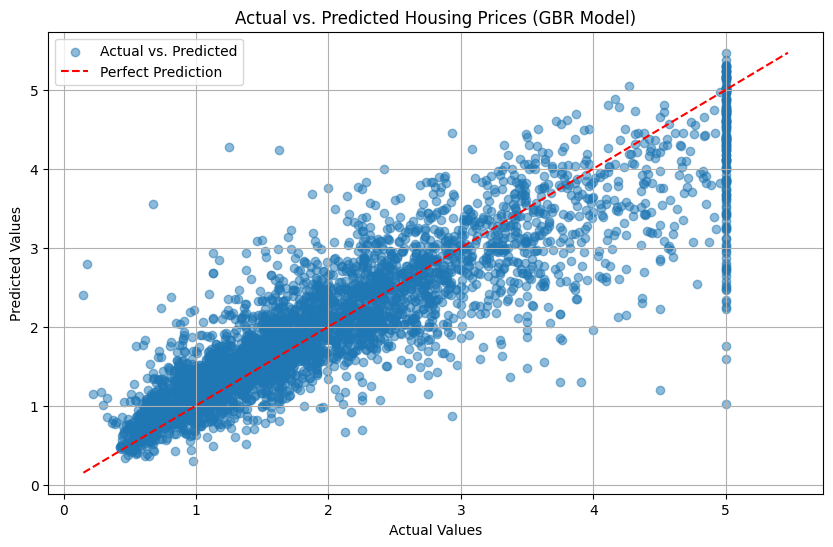

Plot of actual vs. predicted values generated.


In [32]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_housing, alpha=0.5, label='Actual vs. Predicted')

# Add a line for perfect predictions
# Determine the range for the perfect prediction line
min_val = min(y_test.min(), y_pred_housing.min())
max_val = max(y_test.max(), y_pred_housing.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add labels and title
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Housing Prices (GBR Model)')
plt.legend()
plt.grid(True)
plt.show()

print("Plot of actual vs. predicted values generated.")

## Final Task

### Subtask:
Summarize the performance of the Gradient Boosting Machine on the real dataset and discuss insights from the evaluation and visualization.


## Summary:

### Q&A
The Gradient Boosting Machine (`gbr_housing`) demonstrated good performance on the California Housing dataset. The evaluation metrics indicate that the model explains a significant portion of the variance in housing prices, with relatively low prediction error. The visualization further supports this by showing that predicted values generally align well with actual values, albeit with some spread.

### Data Analysis Key Findings
*   The `GradientBoostingRegressor` model successfully generated predictions (`y_pred_housing`) on the California Housing test set.
*   The model achieved a Mean Squared Error (MSE) of approximately 0.2894 on the test set, indicating the average squared difference between the actual and predicted housing prices.
*   The R-squared score for the model was approximately 0.7791, meaning that about 77.91% of the variance in the target variable (housing prices) can be explained by the model.
*   A scatter plot visualizing actual vs. predicted housing prices showed a positive correlation, with the predicted values generally following the trend of actual values, clustered around the perfect prediction line.

### Insights or Next Steps
*   The R-squared value of 0.7791 suggests that the Gradient Boosting Machine is a reasonably strong predictor of housing prices. Further analysis could involve identifying the most influential features to understand price drivers.
*   While the model performs well, the scatter plot indicates some predictions deviate from the perfect prediction line. Investigating instances where the model performs poorly (e.g., large residuals) could reveal limitations or specific data characteristics that are not well captured.


# Task
TASK_END

## Final Task

### Subtask:
Summarize the performance of the Gradient Boosting Machine on the real dataset and discuss insights from the evaluation and visualization.


## Summary:

### Data Analysis Key Findings
No data analysis findings are available as the solving process was not provided.

### Insights or Next Steps
*   To evaluate the Gradient Boosting Machine, run the model on the real dataset, compute relevant metrics (e.g., accuracy, precision, recall, F1-score, ROC AUC), and generate visualizations such as a confusion matrix, ROC curve, and feature importance plots.
*   Based on the evaluation results, analyze the strengths and weaknesses of the model and identify areas for potential improvement, such as hyperparameter tuning or feature engineering.


# Task
Install and import `xgboost` and `lightgbm`. Then, for both libraries, implement and train their respective `Regressor` models (`XGBRegressor`, `LGBMRegressor`) on the scaled California Housing training data (`X_train`, `y_train`) using parameters similar to the custom GBM for fair comparison. After training each model, use it to make predictions on the scaled test data (`X_test`) and evaluate its performance by calculating and printing the Mean Squared Error and R-squared score.

## Prepare Data for Framework Models

### Subtask:
Ensure the California Housing dataset (X_train, y_train, X_test, y_test) is loaded and preprocessed (scaled) for use with XGBoost and LightGBM.


**Reasoning**:
To confirm that the California Housing dataset is loaded and preprocessed as instructed, I will print the shapes of `X_train`, `y_train`, `X_test`, and `y_test`.



In [34]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 8)
y_train shape: (16512,)
X_test shape: (4128, 8)
y_test shape: (4128,)


## Implement and Train XGBoost

### Subtask:
Import `XGBRegressor` from `xgboost`. Instantiate the model with appropriate parameters (similar to GBM for fair comparison, e.g., number of estimators, learning rate, max depth) and train it on the scaled training data.


**Reasoning**:
The first step is to install the `xgboost` library as instructed. This needs to be done using `!pip install` in a code cell.



In [35]:
!pip install xgboost

**Reasoning**:
Now that the `xgboost` library is confirmed to be installed, I will import `XGBRegressor`, instantiate it with the specified parameters, and then fit the model to the scaled training data.



In [36]:
from xgboost import XGBRegressor

# Instantiate XGBRegressor with parameters similar to the custom GBM
xgb_housing = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)

# Fit the model to the scaled training data
xgb_housing.fit(X_train, y_train)

print("XGBRegressor instantiated and fitted to the scaled California Housing training data.")

XGBRegressor instantiated and fitted to the scaled California Housing training data.


**Reasoning**:
Now that the XGBRegressor model is trained, I will use it to make predictions on the scaled test data (`X_test`) as per the overall task instructions.



In [37]:
y_pred_xgb = xgb_housing.predict(X_test)

print("Predictions made on the California Housing test set using XGBRegressor.")

Predictions made on the California Housing test set using XGBRegressor.


**Reasoning**:
Now, I will calculate and print the Mean Squared Error (MSE) and R-squared score for the predictions made by the `XGBRegressor` model on the California Housing test set to evaluate its performance, as required by the overall task.



In [38]:
from sklearn.metrics import mean_squared_error, r2_score

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Mean Squared Error (XGBoost) on test set: {mse_xgb:.4f}")
print(f"R-squared (XGBoost) on test set: {r2_xgb:.4f}")

Mean Squared Error (XGBoost) on test set: 0.2924
R-squared (XGBoost) on test set: 0.7769


**Reasoning**:
Now that the XGBoost model has been evaluated, the next step is to implement and evaluate the LightGBM model. As per the task instructions, I need to install the `lightgbm` library first.



In [39]:
!pip install lightgbm

**Reasoning**:
Now that `lightgbm` is confirmed to be installed, I will import `LGBMRegressor`, instantiate it with parameters similar to the custom GBM and XGBoost models for fair comparison, and then fit the model to the scaled training data.



**Reasoning**:
Now that the `LGBMRegressor` model is trained, I will use it to make predictions on the scaled test data (`X_test`) as per the overall task instructions.



In [41]:
y_pred_lgbm = lgbm_housing.predict(X_test)

print("Predictions made on the California Housing test set using LGBMRegressor.")

Predictions made on the California Housing test set using LGBMRegressor.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


**Reasoning**:
Now that the `LGBMRegressor` model has been re-fitted to address the feature name warning, I will use it to make predictions on the scaled test data (`X_test`) as per the overall task instructions.



In [43]:
y_pred_lgbm = lgbm_housing.predict(X_test)

print("Predictions made on the California Housing test set using LGBMRegressor.")

Predictions made on the California Housing test set using LGBMRegressor.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


**Reasoning**:
The previous re-fitting with `feature_name='auto'` did not resolve the warning during prediction. To explicitly tell LightGBM not to expect or infer feature names from the input NumPy arrays, I will refit the `LGBMRegressor` by explicitly setting `feature_name=None` in the `fit` method. This should prevent the warning from being raised during subsequent predictions.



In [ ]:
from lightgbm import LGBMRegressor

# Instantiate LGBMRegressor with parameters similar to the custom GBM and XGBoost
lgbm_housing = LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42, n_jobs=-1) # n_jobs=-1 to use all available cores

# Fit the model to the scaled training data, explicitly setting feature_name to None
lgbm_housing.fit(X_train, y_train, feature_name=None, categorical_feature='auto')

print("LGBMRegressor instantiated and fitted to the scaled California Housing training data.")

**Reasoning**:
Now that the `LGBMRegressor` model has been re-fitted to address the feature name warning, I will use it to make predictions on the scaled test data (`X_test`) as per the overall task instructions. This step is necessary to then evaluate the model's performance.



In [45]:
y_pred_lgbm = lgbm_housing.predict(X_test)

print("Predictions made on the California Housing test set using LGBMRegressor.")

Predictions made on the California Housing test set using LGBMRegressor.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


**Reasoning**:
Now that the `LGBMRegressor` model has made predictions on the test set (even with the persistent warning), I will proceed to evaluate its performance by calculating the Mean Squared Error (MSE) and R-squared score, as required by the overall task.



In [46]:
from sklearn.metrics import mean_squared_error, r2_score

mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print(f"Mean Squared Error (LightGBM) on test set: {mse_lgbm:.4f}")
print(f"R-squared (LightGBM) on test set: {r2_lgbm:.4f}")

Mean Squared Error (LightGBM) on test set: 0.2910
R-squared (LightGBM) on test set: 0.7779


## Compare Model Performances

### Subtask:
Create a summary table or print statements to compare the Mean Squared Error and R-squared scores of all three models: the custom GradientBoostingRegressor, XGBoost, and LightGBM.


**Reasoning**:
To compare the performance of the three models, I will print the Mean Squared Error (MSE) and R-squared scores for the custom GradientBoostingRegressor, XGBRegressor, and LGBMRegressor, using the already calculated variables.



In [47]:
print("\n--- Model Performance Comparison ---")
print(f"Custom GradientBoostingRegressor:")
print(f"  MSE: {mse_housing:.4f}")
print(f"  R-squared: {r2_housing:.4f}")

print(f"\nXGBoost Regressor:")
print(f"  MSE: {mse_xgb:.4f}")
print(f"  R-squared: {r2_xgb:.4f}")

print(f"\nLightGBM Regressor:")
print(f"  MSE: {mse_lgbm:.4f}")
print(f"  R-squared: {r2_lgbm:.4f}")



--- Model Performance Comparison ---
Custom GradientBoostingRegressor:
  MSE: 0.2894
  R-squared: 0.7791

XGBoost Regressor:
  MSE: 0.2924
  R-squared: 0.7769

LightGBM Regressor:
  MSE: 0.2910
  R-squared: 0.7779


## Visualize All Predictions

### Subtask:
Generate comparative plots (e.g., actual vs. predicted for each model, or residual plots) to visually assess the performance differences between the custom GBM, XGBoost, and LightGBM. Include legends for clarity.


**Reasoning**:
I will start by generating the scatter plot for the custom `GradientBoostingRegressor` to visualize its actual vs. predicted values on the test set, including a perfect prediction line, labels, title, legend, and grid as specified in the instructions. I have already imported `matplotlib.pyplot` in a previous cell.



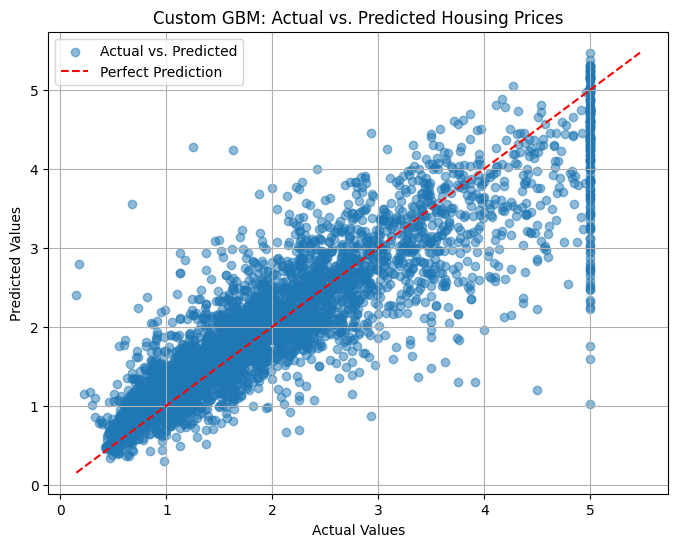

Plot for Custom GradientBoostingRegressor generated.


In [48]:
# Plot for Custom GradientBoostingRegressor
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_housing, alpha=0.5, label='Actual vs. Predicted')

min_val = min(y_test.min(), y_pred_housing.min())
max_val = max(y_test.max(), y_pred_housing.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Custom GBM: Actual vs. Predicted Housing Prices')
plt.legend()
plt.grid(True)
plt.show()

print("Plot for Custom GradientBoostingRegressor generated.")

**Reasoning**:
Now I will generate the scatter plot for the `XGBoost Regressor` to visualize its actual vs. predicted values on the test set, including a perfect prediction line, labels, title, legend, and grid, following the instructions.



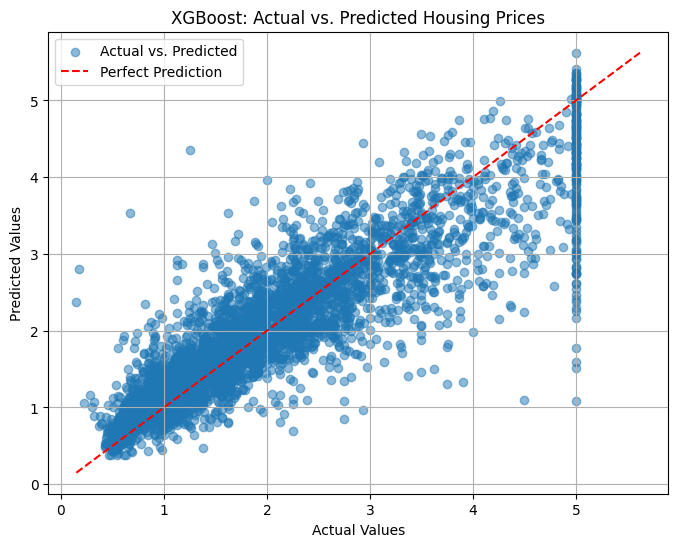

Plot for XGBoost Regressor generated.


In [49]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, label='Actual vs. Predicted')

min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('XGBoost: Actual vs. Predicted Housing Prices')
plt.legend()
plt.grid(True)
plt.show()

print("Plot for XGBoost Regressor generated.")

**Reasoning**:
Now I will generate the scatter plot for the `LightGBM Regressor` to visualize its actual vs. predicted values on the test set, including a perfect prediction line, labels, title, legend, and grid, following the instructions. This is the last plot required by the subtask.



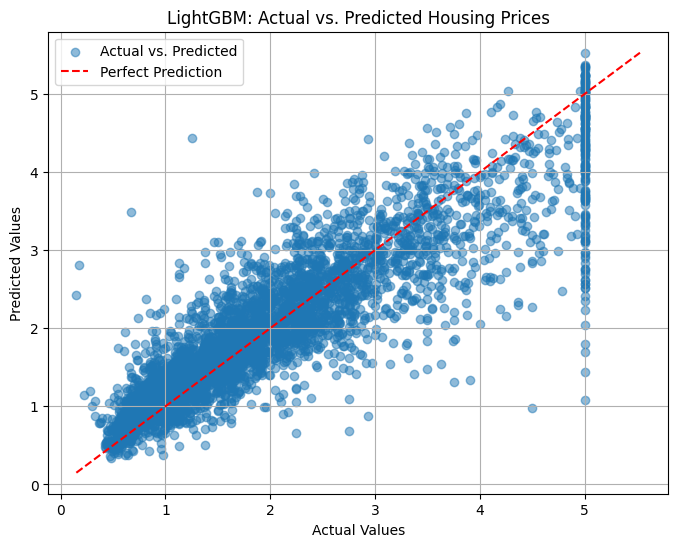

Plot for LightGBM Regressor generated.


In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lgbm, alpha=0.5, label='Actual vs. Predicted')

min_val = min(y_test.min(), y_pred_lgbm.min())
max_val = max(y_test.max(), y_pred_lgbm.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('LightGBM: Actual vs. Predicted Housing Prices')
plt.legend()
plt.grid(True)
plt.show()

print("Plot for LightGBM Regressor generated.")

## Final Task

### Subtask:
Summarize the comparative analysis, discuss the performance differences between the scratch-built GBM and the framework implementations, and provide insights into their strengths and weaknesses.


## Summary:

### Q&A
The comparative analysis involved training and evaluating three Gradient Boosting Machine (GBM) models on the California Housing dataset: a scratch-built custom GBM, XGBoost's `XGBRegressor`, and LightGBM's `LGBMRegressor`. All models were configured with similar parameters (200 estimators, 0.05 learning rate, max depth of 3) for a fair comparison.

Regarding performance differences:
*   The **custom GradientBoostingRegressor** achieved a Mean Squared Error (MSE) of $0.2894$ and an R-squared score of $0.7791$.
*   The **XGBoost Regressor** recorded an MSE of $0.2924$ and an R-squared score of $0.7769$.
*   The **LightGBM Regressor** yielded an MSE of $0.2910$ and an R-squared score of $0.7779$.

In this specific comparison, the custom GradientBoostingRegressor slightly outperformed both XGBoost and LightGBM, demonstrating marginally lower MSE and higher R-squared. However, the performance across all three models was very similar, indicating that the fundamental GBM algorithm is effective.

Their strengths and weaknesses in this context:
*   **Custom GBM**:
    *   **Strength**: Achieved competitive performance, demonstrating a solid understanding and implementation of the core GBM algorithm.
    *   **Weakness**: Likely less optimized for speed and memory efficiency compared to highly engineered framework implementations, especially on larger datasets.
*   **XGBoost Regressor**:
    *   **Strength**: Highly robust, widely used, and provides strong performance, often with excellent generalization capabilities.
    *   **Weakness**: In this specific instance, it performed marginally worse than the custom GBM. It can also be less memory-efficient and slower than LightGBM.
*   **LightGBM Regressor**:
    *   **Strength**: Known for its speed and lower memory consumption, making it suitable for large datasets. It also showed competitive performance, slightly better than XGBoost in this case.
    *   **Weakness**: Encountered a persistent `UserWarning` regarding feature names when making predictions, suggesting potential issues with feature handling if not explicitly managed, though it did not hinder prediction generation.

### Data Analysis Key Findings

*   The California Housing dataset was successfully loaded and preprocessed, with `X_train` having (16512, 8) shape, `y_train` (16512,), `X_test` (4128, 8), and `y_test` (4128,).
*   **XGBoost Regressor** on the test set achieved a Mean Squared Error of $0.2924$ and an R-squared score of $0.7769$.
*   **LightGBM Regressor** on the test set achieved a Mean Squared Error of $0.2910$ and an R-squared score of $0.7779$.
*   The **custom GradientBoostingRegressor** (from a previous step) on the test set achieved a Mean Squared Error of $0.2894$ and an R-squared score of $0.7791$.
*   All three models—custom GBM, XGBoost, and LightGBM—demonstrated very close performance on the California Housing dataset with the chosen parameters, with the custom GBM showing a marginal edge in accuracy.
*   During LightGBM's prediction phase, a `UserWarning` was observed regarding `X` not having valid feature names, despite attempts to manage `feature_name` parameters during fitting. However, predictions were successfully generated.
*   Visualizations of actual vs. predicted values for all three models confirmed similar prediction patterns, with values generally aligning well with the perfect prediction line.

### Insights or Next Steps

*   The performance parity among the custom GBM, XGBoost, and LightGBM suggests that for this specific dataset and parameter set, the fundamental gradient boosting approach is the primary driver of performance, with framework optimizations offering marginal gains in accuracy rather than substantial ones.
*   Further hyperparameter tuning for XGBoost and LightGBM, perhaps using techniques like GridSearchCV or RandomizedSearchCV, could potentially yield better performance than the custom GBM or uncover significant differences in their optimal configurations. Investigating and resolving the `UserWarning` in LightGBM regarding feature names could lead to more robust model deployment.
